Wczytywanie danych...
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Rozpoczynanie strojenia (KerasTuner)...
Reloading Tuner from tuning\dog_breed_tuner\tuner0.json
Najlepsze parametry: {'units': 192, 'dropout': 0.4161969196444468, 'learning_rate': 0.0001}
Rozpoczynanie finalnego treningu z logowaniem MLflow...
Epoch 1/5


C:\Users\dstas\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


515/515 ━━━━━━━━━━━━━━━━━━━━ 97s 185ms/step - accuracy: 0.5766 - loss: 1.5440 - val_accuracy: 0.8083 - val_loss: 0.7738
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 95s 185ms/step - accuracy: 0.5965 - loss: 1.4609 - val_accuracy: 0.8141 - val_loss: 0.7223
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 94s 182ms/step - accuracy: 0.6104 - loss: 1.3869 - val_accuracy: 0.8158 - val_loss: 0.6910
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 94s 183ms/step - accuracy: 0.6189 - loss: 1.3563 - val_accuracy: 0.8202 - val_loss: 0.6678
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 94s 182ms/step - accuracy: 0.6339 - loss: 1.3068 - val_accuracy: 0.8146 - val_loss: 0.6530


2026/06/24 00:50:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 00:50:12 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Model zapisany w MLflow.


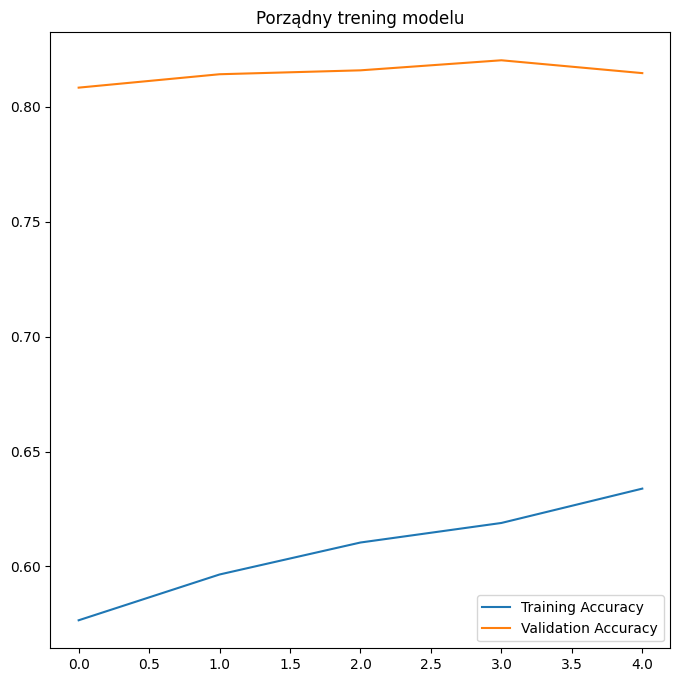

In [8]:
# --- KOMÓRKA 1: Importy i Konfiguracja ---
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
import matplotlib.pyplot as plt
import mlflow
import mlflow.keras
import keras_tuner as kt
import os

# Konfiguracja eksperymentu
EXPERIMENT_NAME = "Dog_Breed_Classification_Pro"
mlflow.set_experiment(EXPERIMENT_NAME)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = 'data/Images'

# --- KOMÓRKA 2: Ładowanie danych ---
print("Wczytywanie danych...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
class_names = train_ds.class_names
num_classes = len(class_names)

# --- KOMÓRKA 3: Inżynieria cech (Data Augmentation) ---
# To zwiększa odporność modelu na warianty zdjęć
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="data_augmentation")

# --- KOMÓRKA 4: Model bazowy (MobileNetV2) ---
def get_base_model():
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    return base_model

# --- KOMÓRKA 5: Strojenie hiperparametrów (KerasTuner) ---
# To spełnia wymóg AutoML/Hyperparameter Tuning
def build_model(hp):
    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        # TU JEST POPRAWKA: Używamy layers.Lambda, żeby zamienić funkcję w warstwę
        layers.Rescaling(scale=1./127.5, offset=-1),
        get_base_model(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(units=hp.Int('units', 64, 256, step=64), activation='relu'),
        layers.Dropout(rate=hp.Float('dropout', 0.2, 0.5)),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', [1e-3, 1e-4])),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Rozpoczynanie strojenia (KerasTuner)...")
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    directory='tuning',
    project_name='dog_breed_tuner'
)
tuner.search(train_ds, validation_data=val_ds, epochs=5)
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Najlepsze parametry: {best_hps.values}")

# --- KOMÓRKA 6: Trenowanie z MLflow (System śledzenia) ---
# Tutaj logujemy finalny, najlepszy model do MLflow
print("Rozpoczynanie finalnego treningu z logowaniem MLflow...")
with mlflow.start_run(run_name="Final_Tuned_Model"):
    mlflow.log_params(best_hps.values)
    
    history = best_model.fit(train_ds, validation_data=val_ds, epochs=5)
    
    # Logowanie metryk
    mlflow.log_metric("final_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("final_val_accuracy", history.history['val_accuracy'][-1])
    
    # Zapis modelu
    mlflow.keras.log_model(best_model, "model")
    print("Model zapisany w MLflow.")

# --- KOMÓRKA 7: Wizualizacja porównania ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.figure(figsize=(8, 8))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Porządny trening modelu')
plt.show()

In [2]:
model.save('dog_baseline_model.keras')
print("Model zapisany!")

Model zapisany!


In [3]:
import json

# Zapisujemy listę ras do pliku
with open('models/class_names.json', 'w') as f:
    json.dump(class_names, f)
print("Nazwy ras zapisane!")

Nazwy ras zapisane!


In [9]:
import os

os.makedirs('models', exist_ok=True)

best_model.save('models/best_model.keras')

print("Model został zapisany w folderze models/ pod nazwą best_model.keras")

Model został zapisany w folderze models/ pod nazwą best_model.keras
